In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm
from os.path import join

In [11]:
BASE_DIR = r"C:\Users\elira\ShmilaJustSolveIt Dropbox\Eliran Shmila\PC\Documents\Thesis"
csv_dir = join(BASE_DIR, "CSVs")
os.listdir(csv_dir)

['2projects combined labels.xlsx',
 '2projects combined-proteinGroups-genes.csv',
 '2projects combined-proteinGroups-genes.xlsx',
 'protein_analysis_csvs_dir',
 'relevant_dataframes_per_norm_type',
 'SlidesZohar.xlsx',
 'top_20_proteins_per_norm_type']

In [12]:
# Read data
proteomics_df = pd.read_excel(join(csv_dir, '2projects combined-proteinGroups-genes.xlsx'))

In [13]:
def get_protein_row(protein_name, proteomics_df):
    protein_mask = proteomics_df['Protein names'].str.contains(protein_name, na=False, case=False)
    if not protein_mask.any():
        print(f"Protein {protein_name} not found.")
        print("Available proteins:")
        print(proteomics_df['Protein names'].head())
        return None
    return proteomics_df[protein_mask].iloc[0]

In [14]:
def process_columns(protein_row, norm_type):
    """
    norm_type: 'Intensity', 'iBAQ', or 'LFQ'
    Returns: list of tuples (patient, position, val)
    """
    prefix = {
        'Intensity': 'Intensity ',
        'iBAQ': 'iBAQ ',
        'LFQ': 'LFQ intensity '
    }[norm_type]
    
    # Get Lysis columns only
    expr_cols = {col: val for col, val in protein_row.items() 
                if col.startswith(prefix) and 
                col.endswith('L') and 
                not pd.isna(val) and 
                val != 0}
    
    data = []
    for col, val in expr_cols.items():
        parts = col.replace(prefix, '').split('_')
        patient = parts[0]
        pos_method = parts[1]
        position = pos_method[:-1]  # Remove 'L'
        data.append((patient, position, val))
    
    return sorted(data, key=lambda x: (int(x[0]), int(x[1])))

In [15]:
def plot_protein_expression(protein_row, proteomics_df, include_single_samples=False):
    fig, axes = plt.subplots(3, 1, figsize=(20, 15))
    fig.suptitle(f'Expression Levels for {protein_row["Protein names"]} Across Patients and Positions')

    norm_types = ['Intensity', 'iBAQ', 'LFQ']

    for idx, norm_type in enumerate(tqdm(norm_types, desc="Processing normalization types")):
        data = process_columns(protein_row, norm_type)

        if not data:
            print(f"No data found for {norm_type}")
            continue

        x_coords = list(range(len(data)))
        y_values = [val for patient, pos, val in data]
        labels = [f"({p},{pos}L)" for p, pos, _ in data]

        # Group measurements by patient
        patient_measurements = {}
        for patient, pos, val in data:
            if patient not in patient_measurements:
                patient_measurements[patient] = []
            patient_measurements[patient].append(val)

        # Calculate stats based on measurement count criteria
        patient_ranges = []
        patient_stats = {}
        start_idx = 0
        curr_idx = 0
        patient_means_for_cv = []

        for patient, measurements in patient_measurements.items():
            mean_val = np.mean(measurements)

            # Decide whether to include this patient's mean in CV calculation
            if include_single_samples or len(measurements) >= 3:
                patient_means_for_cv.append(mean_val)

            # Only add visualization elements for patients with multiple measurements
            if len(measurements) > 1:
                std_val = np.std(measurements)
                cv = (std_val / mean_val) * 100 if mean_val != 0 else 0
                end_idx = curr_idx + len(measurements) - 1

                patient_ranges.append((start_idx, end_idx))
                patient_stats[patient] = {
                    'mean': mean_val,
                    'std': std_val,
                    'cv': cv,
                    'n': len(measurements)
                }

            curr_idx += len(measurements)
            start_idx = curr_idx

        # Calculate CV of means
        cv_of_means = (np.std(patient_means_for_cv) / np.mean(patient_means_for_cv)) * 100 if patient_means_for_cv else 0

        ax = axes[idx]
        ax.scatter(x_coords, y_values, c='blue', s=50, alpha=0.7)

        # Mean lines and std bands for patients with multiple measurements
        for (start, end), patient in zip(patient_ranges, patient_stats.keys()):
            stats = patient_stats[patient]
            mean_val = stats['mean']
            std_val = stats['std']

            # Plot mean line
            ax.hlines(mean_val, start, end, colors='red', linestyles='--', alpha=0.7)

            # Add standard deviation band
            ax.fill_between(range(start, end+1),
                        [mean_val - std_val] * (end-start+1),
                        [mean_val + std_val] * (end-start+1),
                        color='red', alpha=0.1)

        # Add CV annotation
        ax.text(0.02, 0.98, f'CV of means: {cv_of_means:.2f}%',
               transform=ax.transAxes, va='top', fontsize=10,
               bbox=dict(facecolor='white', alpha=0.8))

        # Calculate overall statistics
        overall_mean = np.mean(y_values)
        ax.axhline(y=overall_mean, color='green', linestyle='-', alpha=0.5)

        # Formatting
        ax.set_xticks(x_coords)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        ax.set_title(f'{norm_type} Normalization')
        ax.set_ylabel('Expression Level')
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    plt.tight_layout()
    return fig

In [19]:
# protein_name = "DNA-directed RNA polymerases I and III subunit RPAC2"
protein_name = "Thioredoxin"
# protein_name = "UV excision repair protein RAD23 homolog B"
# protein_name = "Elongation factor 1-alpha 1; Putative elongation factor 1-alpha-like 3"

Processing normalization types: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 11.66it/s]


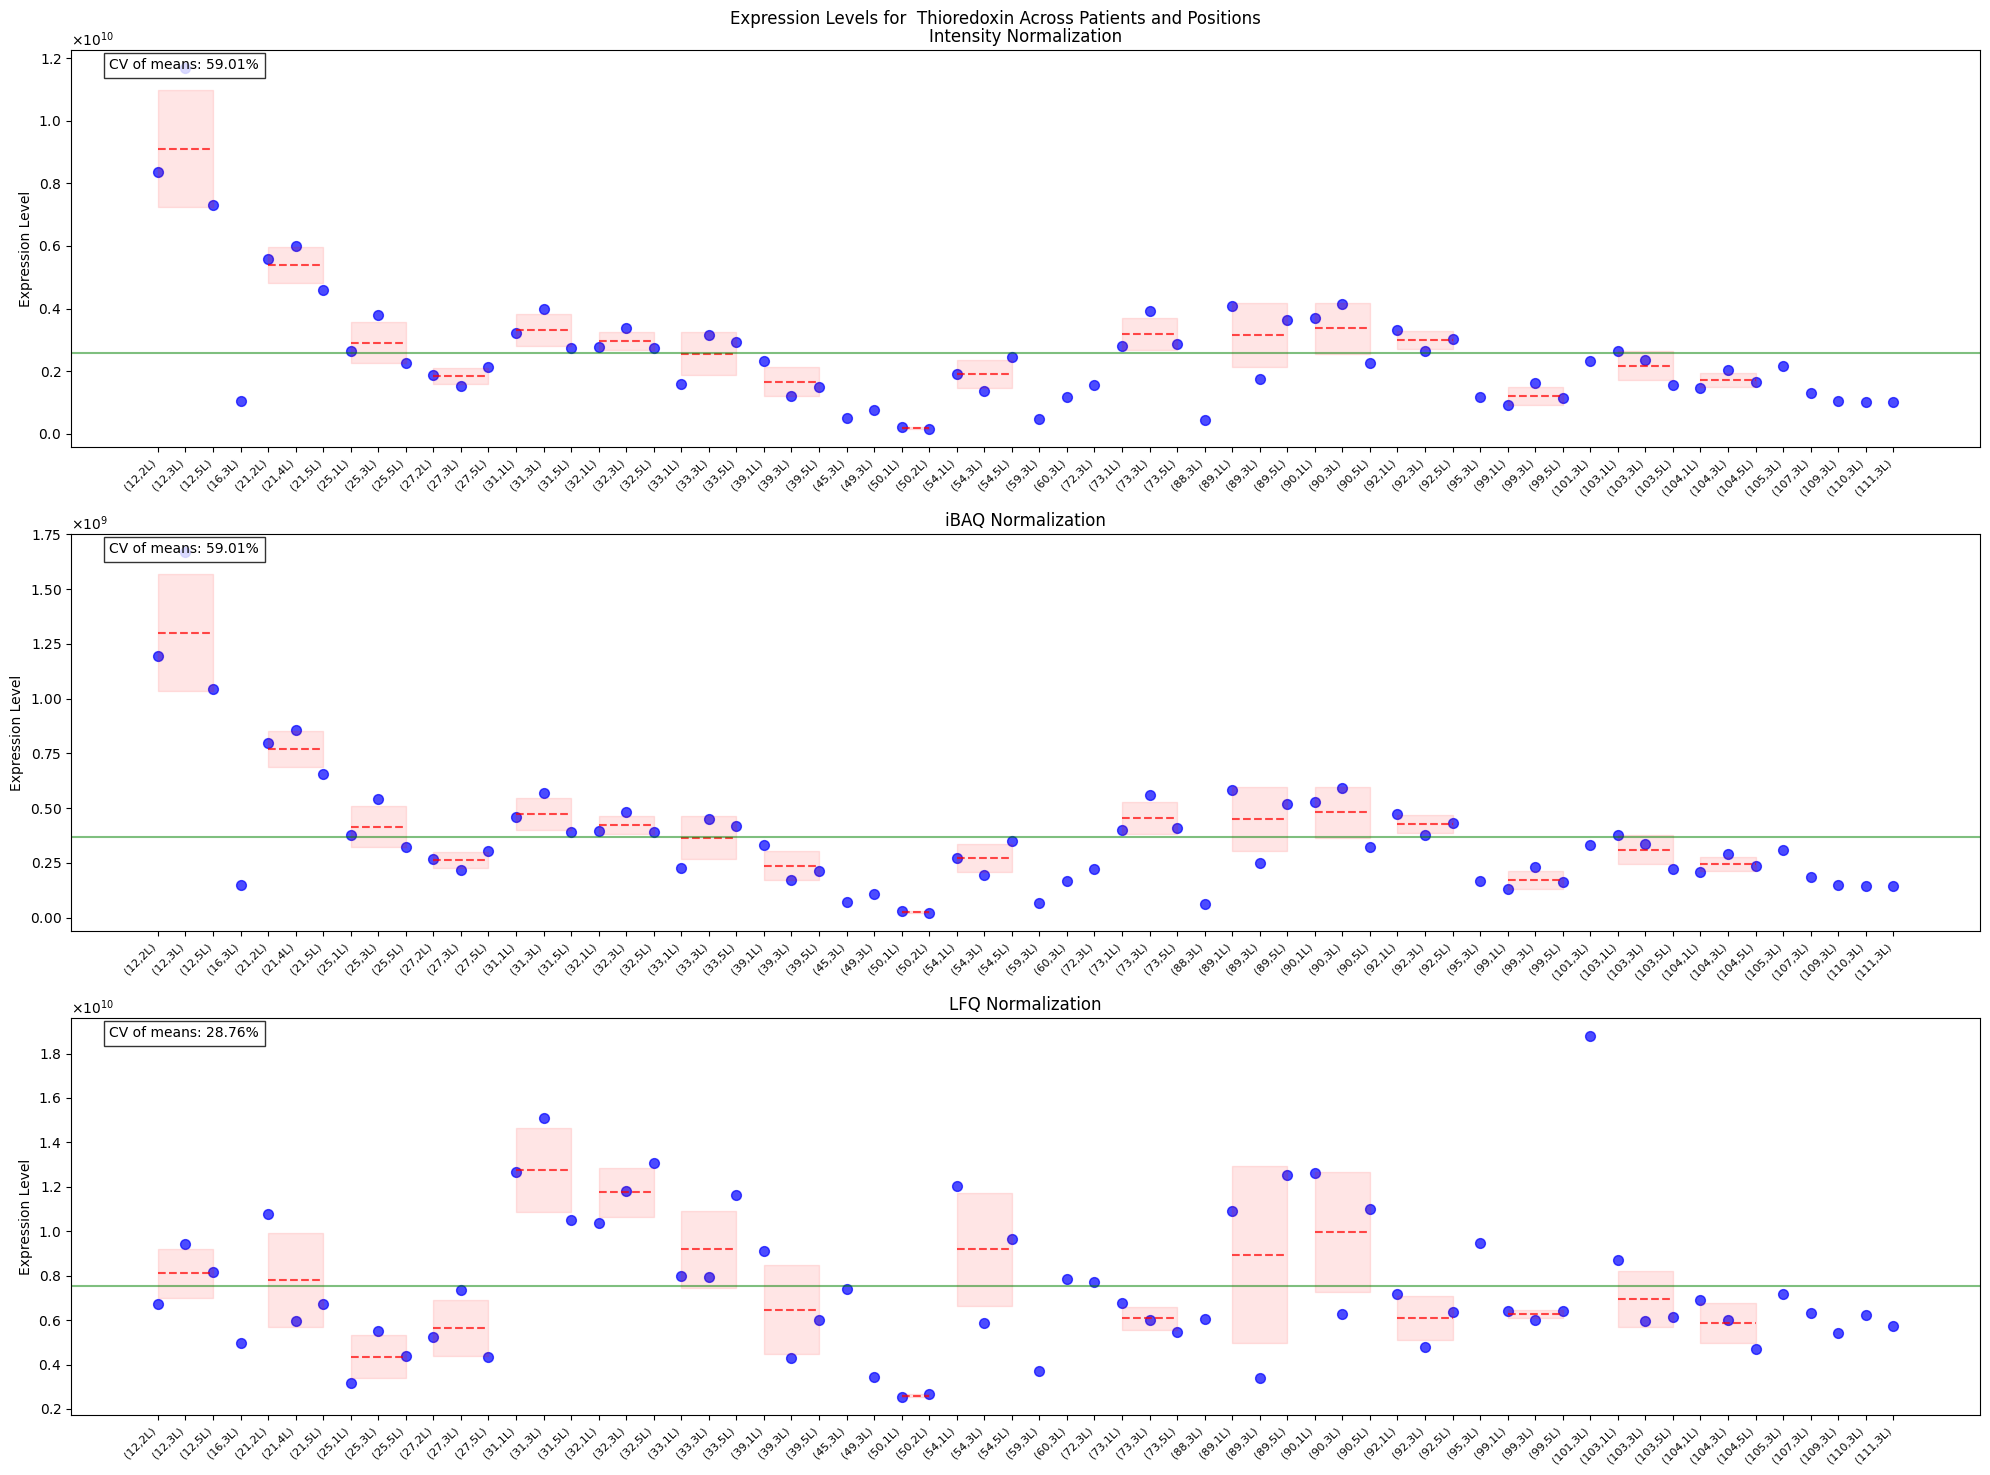

In [20]:
# Get protein row once:
protein_row = get_protein_row(protein_name, proteomics_df)
if protein_row is not None:
    fig = plot_protein_expression(protein_row, proteomics_df)
    plt.show() 
#     plt.savefig('protein_expression_scatter.png', dpi=300, bbox_inches='tight')
    plt.close()

In [27]:
def debug_thioredoxin_data():
    # Load and print data for Thioredoxin from both files
    for norm_type in ['Intensity', 'iBAQ']:
        # Load the file used by the plot-
        df = pd.read_csv(f'relevant_patients_proteomics_table_{norm_type}.csv')
        thioredoxin_row = df[df['Protein names'].fillna('').str.contains('Thioredoxin', case=False, na=False)].iloc[0]
        
        print(f"\n{norm_type} measurements for Thioredoxin:")
        columns_with_values = {}
        for col in df.columns:
            if col.endswith('L') and not pd.isna(thioredoxin_row[col]):
                columns_with_values[col] = thioredoxin_row[col]
                print(f"{col}: {thioredoxin_row[col]}")
                
        # Calculate mean and CV directly
        values = list(columns_with_values.values())
        patient_means = []
        patient_values = {}
        
        for col, val in columns_with_values.items():
            patient = col.split('_')[1].split('L')[0] if norm_type == 'Intensity' else col.split(' ')[1].split('L')[0]
            if patient not in patient_values:
                patient_values[patient] = []
            patient_values[patient].append(val)
            
        for patient, vals in patient_values.items():
            patient_means.append(np.mean(vals))
            
        cv = np.std(patient_means) / np.mean(patient_means) * 100
        print(f"\nCalculated CV of means: {cv}")
        
        # Load and check the dashboard file
        df2 = pd.read_csv(f'{norm_type}_protein_analysis.csv')
        thio_analysis = df2[df2['Protein names'].fillna('').str.contains('Thioredoxin', case=False, na=False)].iloc[0]
        print(f"\nDashboard Patient Measurements:")
        print(f"Average CV from dashboard: {thio_analysis['Average CV']}")
        print(f"Patient measurements: {thio_analysis['Patient Measurements']}")